In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler, StandardScaler
#

# kiểm tra dataset

In [2]:
name_path = 'New_York_Air_Quality.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-01-01 00:00:00+00:00,New York,304.0,49.6,8.2,17.0,10.0,11.8,26.375000
1,2025-01-01 01:00:00+00:00,New York,289.0,43.3,7.1,26.0,8.8,10.4,26.183334
2,2025-01-01 02:00:00+00:00,New York,269.0,34.5,5.6,38.0,7.4,8.8,25.924997
3,2025-01-01 03:00:00+00:00,New York,248.0,27.4,4.3,48.0,6.4,7.8,25.550000
4,2025-01-01 04:00:00+00:00,New York,224.0,23.4,3.5,54.0,6.0,7.4,25.066664


# kiểm tra các giá trị thiếu 

In [3]:

print("Tổng số giá trị bị thiếu (NaN):")
print(df.isnull().sum())


Tổng số giá trị bị thiếu (NaN):
Date     0
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
AQI      0
dtype: int64


--- BẮT ĐẦU XỬ LÝ OUTLIERS ---
Cột 'CO': Tìm thấy 483 giá trị ngoại lai.
Cột 'NO2': Tìm thấy 204 giá trị ngoại lai.
Cột 'SO2': Tìm thấy 192 giá trị ngoại lai.
Cột 'O3': Tìm thấy 354 giá trị ngoại lai.
Cột 'PM2.5': Tìm thấy 326 giá trị ngoại lai.
Cột 'PM10': Tìm thấy 297 giá trị ngoại lai.
Cột 'AQI': Tìm thấy 649 giá trị ngoại lai.


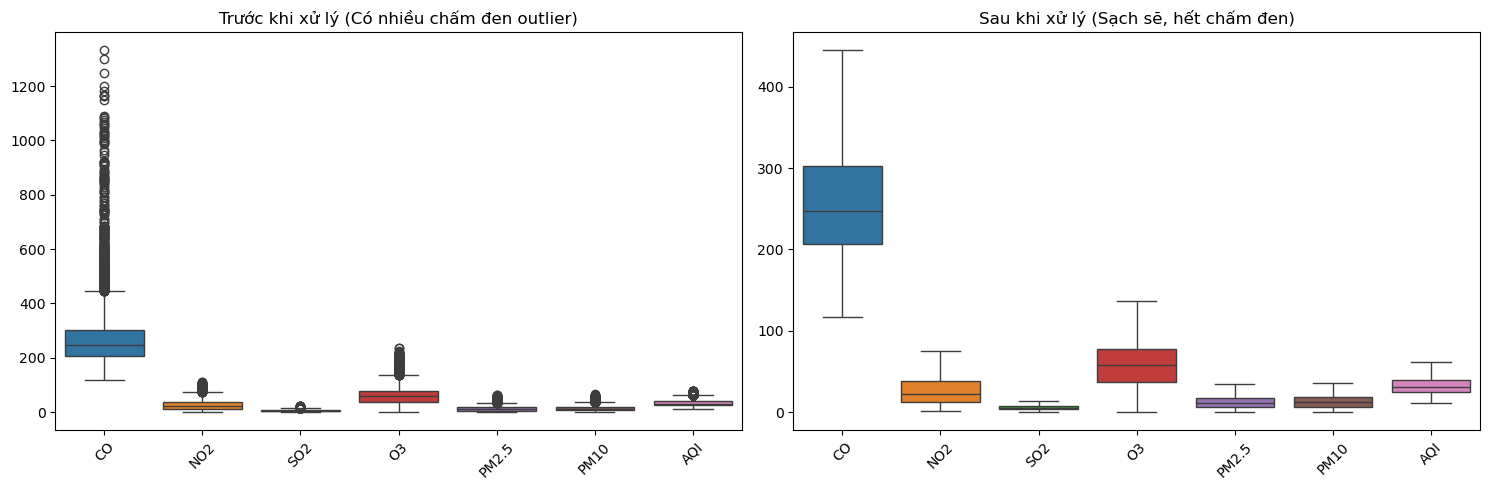

In [4]:
# 1. Hàm xử lý Outlier bằng phương pháp IQR Capping
def handle_outliers_iqr(df, column_name):
    # Tính toán Q1 (25%), Q3 (75%) và IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # Xác định biên dưới và biên trên
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Đếm xem có bao nhiêu outlier trước khi xử lý
    outliers_count = ((df[column_name] < lower_bound) | (df[column_name] > upper_bound)).sum()
    print(f"Cột '{column_name}': Tìm thấy {outliers_count} giá trị ngoại lai.")
    
    # Capping (Kìm kẹp): Thay giá trị > upper bằng upper, < lower bằng lower
    # Dùng hàm clip để cắt ngọn
    df[column_name] = df[column_name].clip(lower=lower_bound, upper=upper_bound)
    
    return df

# 2. Áp dụng cho tất cả các cột số (Numeric Columns)
# Lấy danh sách các cột chứa số (loại bỏ cột ngày tháng hoặc tên thành phố)
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("--- BẮT ĐẦU XỬ LÝ OUTLIERS ---")

# Vẽ biểu đồ Boxplot TRƯỚC khi xử lý (để so sánh)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df[numeric_cols])
plt.title("Trước khi xử lý (Có nhiều chấm đen outlier)")
plt.xticks(rotation=45)

# Chạy vòng lặp xử lý từng cột
for col in numeric_cols:
    df = handle_outliers_iqr(df, col)

# Vẽ biểu đồ Boxplot SAU khi xử lý
plt.subplot(1, 2, 2)
sns.boxplot(data=df[numeric_cols])
plt.title("Sau khi xử lý (Sạch sẽ, hết chấm đen)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

--- Kiểm tra tính dừng (ADF Test): Dữ liệu Gốc ---
1. ADF Statistic: -10.4416
2. p-value: 0.0000
✅ KẾT LUẬN: Dữ liệu ĐÃ DỪNG (Stationary).
   (Mean và Variance đã ổn định theo thời gian)
--------------------------------------------------


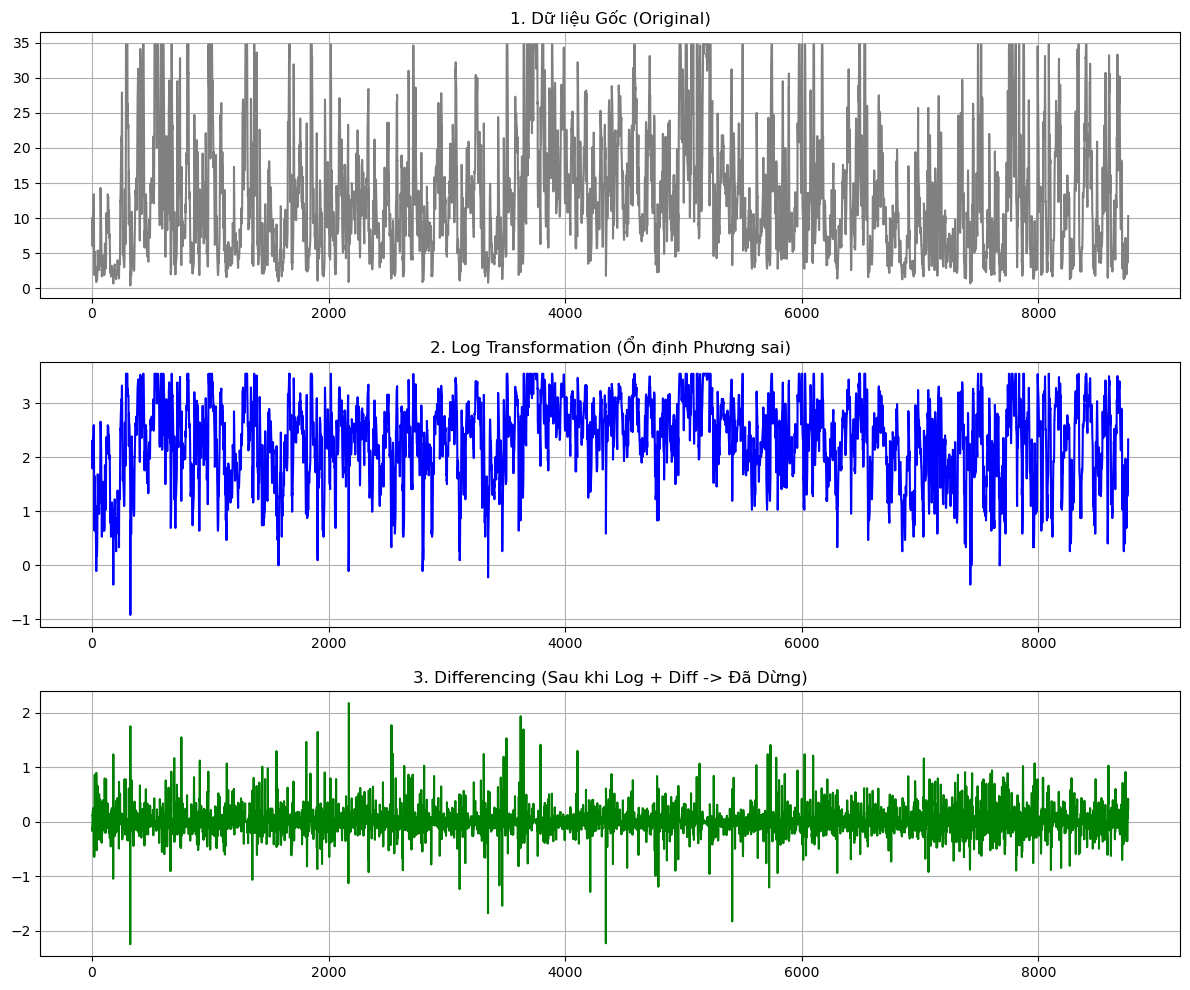

--- Kiểm tra tính dừng (ADF Test): Dữ liệu sau khi xử lý (Log + Diff) ---
1. ADF Statistic: -21.2647
2. p-value: 0.0000
✅ KẾT LUẬN: Dữ liệu ĐÃ DỪNG (Stationary).
   (Mean và Variance đã ổn định theo thời gian)
--------------------------------------------------


In [5]:

def check_stationarity(timeseries, title):
    print(f"--- Kiểm tra tính dừng (ADF Test): {title} ---")
    result = adfuller(timeseries.dropna()) # Bỏ NaN trước khi kiểm tra
    p_value = result[1]
    
    print(f"1. ADF Statistic: {result[0]:.4f}")
    print(f"2. p-value: {result[1]:.4f}")
    
    if p_value <= 0.05:
        print("✅ KẾT LUẬN: Dữ liệu ĐÃ DỪNG (Stationary).")
        print("   (Mean và Variance đã ổn định theo thời gian)")
    else:
        print("❌ KẾT LUẬN: Dữ liệu CHƯA DỪNG (Non-Stationary).")
        print("   (Vẫn còn xu hướng hoặc phương sai thay đổi)")
    print("-" * 50)


# 1. Lấy dữ liệu gốc (đã xử lý Missing/Outlier ở bước trước)
ts_original = df['PM2.5']

plt.figure(figsize=(12, 10))

# --- BƯỚC A: DỮ LIỆU GỐC ---
plt.subplot(3, 1, 1)
plt.plot(ts_original, color='gray')
plt.title('1. Dữ liệu Gốc (Original)')
plt.grid(True)
check_stationarity(ts_original, "Dữ liệu Gốc")

# --- BƯỚC B: LOG TRANSFORMATION (Ổn định Phương sai - Variance) ---
# Kỹ thuật: "Variance Stabilization" trong hình
# Cộng 1e-6 để tránh lỗi log(0)
ts_log = np.log(ts_original + 1e-6)

plt.subplot(3, 1, 2)
plt.plot(ts_log, color='blue')
plt.title('2. Log Transformation (Ổn định Phương sai)')
plt.grid(True)

# --- BƯỚC C: DIFFERENCING (Ổn định Trung bình - Mean) ---
# Kỹ thuật: "Differencing: Removes trends" trong hình
# Lấy giá trị hiện tại trừ giá trị trước đó (t - (t-1))
ts_stationary = ts_log.diff(1).dropna()

plt.subplot(3, 1, 3)
plt.plot(ts_stationary, color='green')
plt.title('3. Differencing (Sau khi Log + Diff -> Đã Dừng)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Kiểm tra lại kết quả cuối cùng
check_stationarity(ts_stationary, "Dữ liệu sau khi xử lý (Log + Diff)")

# Lưu biến này để dùng cho mô hình
final_data = ts_stationary

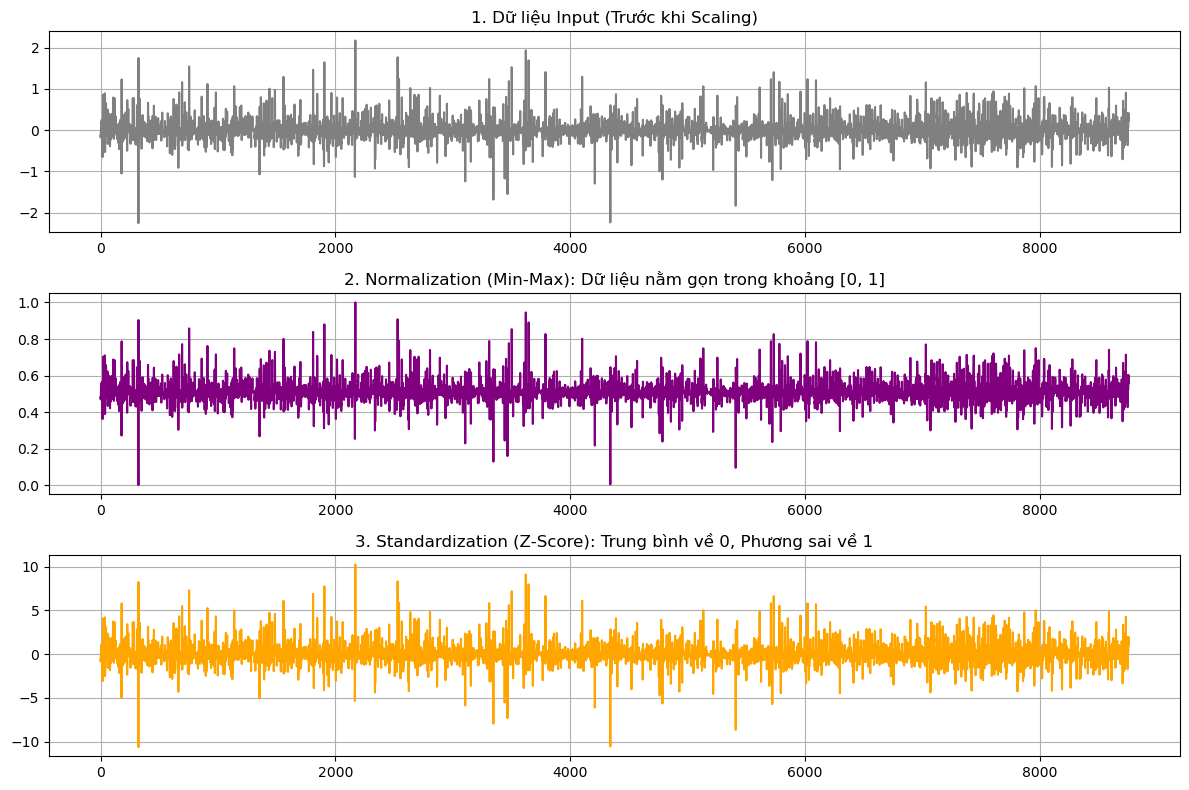

✅ Đã chuẩn hóa xong!
Ví dụ dữ liệu gốc: -0.1278
Ví dụ sau Min-Max: 0.4798
Ví dụ sau Standard: -0.6032


In [6]:

input_data = final_data.values.reshape(-1, 1) # Sklearn bắt buộc phải reshape

plt.figure(figsize=(12, 8))

# --- BIỂU ĐỒ 1: DỮ LIỆU TRƯỚC KHI SCALING ---
plt.subplot(3, 1, 1)
plt.plot(input_data, color='gray')
plt.title('1. Dữ liệu Input (Trước khi Scaling)')
plt.grid(True)

# ======================================================
# CÁCH 1: NORMALIZATION (Min-Max Scaling)
# ======================================================
# Thường dùng cho Deep Learning (LSTM, RNN)
# Ép dữ liệu về khoảng [0, 1]
scaler_minmax = MinMaxScaler(feature_range=(0, 1))
data_normalized = scaler_minmax.fit_transform(input_data)

plt.subplot(3, 1, 2)
plt.plot(data_normalized, color='purple')
plt.title('2. Normalization (Min-Max): Dữ liệu nằm gọn trong khoảng [0, 1]')
plt.grid(True)

# ======================================================
# CÁCH 2: STANDARDIZATION (Z-Score Scaling)
# ======================================================
# Thường dùng cho các thuật toán thống kê (SVM, Logistic Regression...)
# Đưa dữ liệu về dạng phân phối chuẩn (Mean = 0, Std = 1)
scaler_std = StandardScaler()
data_standardized = scaler_std.fit_transform(input_data)

plt.subplot(3, 1, 3)
plt.plot(data_standardized, color='orange')
plt.title('3. Standardization (Z-Score): Trung bình về 0, Phương sai về 1')
plt.grid(True)

plt.tight_layout()
plt.show()

print("✅ Đã chuẩn hóa xong!")
print(f"Ví dụ dữ liệu gốc: {input_data[0][0]:.4f}")
print(f"Ví dụ sau Min-Max: {data_normalized[0][0]:.4f}")
print(f"Ví dụ sau Standard: {data_standardized[0][0]:.4f}")

# --- LƯU Ý QUAN TRỌNG ---
# Nếu bạn định dùng LSTM, hãy chọn biến 'data_normalized'.
# Nếu bạn dùng mô hình khác, có thể thử 'data_standardized'.
final_scaled_data = data_normalized # Chọn cái này để đi tiếp

In [7]:
df_export_stationary = final_data.to_frame(name='PM2.5_Stationary')

# Lưu file (Nó sẽ nằm ngay cạnh file code của bạn)
filename1 = 'dulieu_da_xu_ly_stationarity.csv'
df_export_stationary.to_csv(filename1)

# ======================================================
# 2. XUẤT DỮ LIỆU ĐÃ CHUẨN HÓA (Scaled - Dùng cho LSTM)
# ======================================================
# Ghép dữ liệu số với ngày tháng
df_export_scaled = pd.DataFrame(
    final_scaled_data, 
    index=final_data.index, 
    columns=['PM2.5_Scaled']
)

# Lưu file
filename2 = 'dulieu_da_chuan_hoa_scaled.csv'
df_export_scaled.to_csv(filename2)

# ======================================================
# 3. THÔNG BÁO VỊ TRÍ FILE
# ======================================================
print("✅ Đã lưu xong 2 file!")
print(f"📂 File nằm tại thư mục này: {os.getcwd()}")
print(f"   1. {filename1}")
print(f"   2. {filename2}")

✅ Đã lưu xong 2 file!
📂 File nằm tại thư mục này: d:\Project DAP\Model
   1. dulieu_da_xu_ly_stationarity.csv
   2. dulieu_da_chuan_hoa_scaled.csv
